In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [26]:
data = pd.read_csv('/content/predict_energy_consumption.xls')
data.head()
data.shape
data.describe()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temperature         1000 non-null   float64
 1   humidity            1000 non-null   float64
 2   wind_speed          1000 non-null   float64
 3   solar_irradiance    1000 non-null   float64
 4   energy_consumption  1000 non-null   float64
dtypes: float64(5)
memory usage: 39.2 KB


In [27]:
X = data[['temperature', 'humidity', 'wind_speed', 'solar_irradiance']].values
y = data['energy_consumption'].values

X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

In [28]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
model = Sequential(
[Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
          Dense(32, activation='relu'),
          Dense(1)
]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2,verbose=1)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 91005.6250 - mae: 272.0009 - val_loss: 90476.0469 - val_mae: 273.1362
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 90607.8125 - mae: 271.2690 - val_loss: 90001.6094 - val_mae: 272.2626
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 90010.8281 - mae: 270.1452 - val_loss: 89209.8594 - val_mae: 270.7961
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 89007.0156 - mae: 268.2892 - val_loss: 87933.7656 - val_mae: 268.4145
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 87411.7969 - mae: 265.3156 - val_loss: 85954.8672 - val_mae: 264.6769
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 85051.1719 - mae: 260.7330 - val_loss: 83028.2656 - val_mae: 259.0515
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 81664.4141 - mae: 254.1272 - val_loss: 79055.4531 - val_mae: 251.2076
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 77155.7344 - mae: 245.1005 - val_loss: 73933.

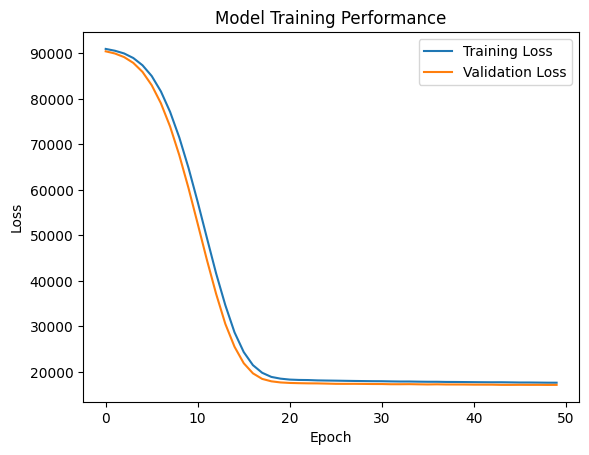

In [31]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Training Performance')
plt.legend()
plt.show()

In [32]:
predictions = model.predict(X_test)
predictions

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([[300.1323 ],
       [253.55966],
       [225.86108],
       [282.38687],
       [266.99805],
       [291.33685],
       [280.81595],
       [325.55237],
       [317.43768],
       [250.57019],
       [278.0443 ],
       [266.6214 ],
       [271.768  ],
       [289.9762 ],
       [228.67545],
       [218.30046],
       [263.05585],
       [277.07196],
       [294.11786],
       [267.36008],
       [257.5423 ],
       [278.0597 ],
       [266.93542],
       [250.58311],
       [310.66153],
       [242.32191],
       [230.23718],
       [227.63452],
       [282.31842],
       [228.33362],
       [270.7326 ],
       [286.598  ],
       [225.92033],
       [273.74268],
       [255.42422],
       [250.03345],
       [273.18463],
       [281.41248],
       [315.35083],
       [308.40143],
       [301.78735],
       [262.52438],
       [269.5467 ],
       [308.48584],
       [226.00844],
       [291.06683],
       [278.6195 ],
       [300.39243],
       [250.83264],
       [263.76697],


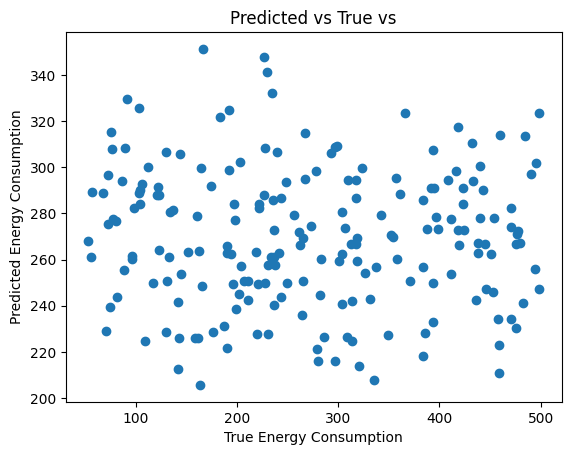

In [35]:
plt.scatter(y_test, predictions)
plt.xlabel('True Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title('Predicted vs True vs')
plt.show()